# Retrieval Precision: Self-RAG With vs Without LangChain

This notebook compares retrieval precision of the Self-RAG pipeline using two chunking strategies:

| | **Without LangChain** | **With LangChain** |
|---|---|---|
| **Splitter** | Naive fixed-size char splitting | `RecursiveCharacterTextSplitter` (hierarchical separators) |
| **Selection** | Sequential (first N chunks) | Keyword-frequency scoring |
| **Context sent** | Entire passage or truncated | Only top-scored chunks |

**Dataset**: `data/full_legalbench_qa.json` — 6,858 legal contract Q&A pairs  
**Metrics**:
- `Precision@K` — does any retrieved chunk contain the ground-truth answer?
- `Answer Coverage` — fraction of answer text present in retrieved context
- `Token Efficiency` — characters sent to LLM vs. full passage length

## 1. Setup & Imports

In [1]:
import json
import re
import sys
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from typing import List, Dict, Tuple, Set

warnings.filterwarnings('ignore')

# Add project root to path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

# Install langchain-text-splitters if not already available
try:
    from langchain.text_splitter import RecursiveCharacterTextSplitter as LCRecursiveSplitter
    LANGCHAIN_AVAILABLE = True
    print('LangChain text splitter loaded from langchain.text_splitter')
except ImportError:
    try:
        from langchain_text_splitters import RecursiveCharacterTextSplitter as LCRecursiveSplitter
        LANGCHAIN_AVAILABLE = True
        print('LangChain text splitter loaded from langchain_text_splitters')
    except ImportError:
        LANGCHAIN_AVAILABLE = False
        print('WARNING: LangChain not installed. Run: pip install langchain-text-splitters')

print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

LangChain text splitter loaded from langchain.text_splitter
NumPy  : 1.26.3
Pandas : 2.2.0


## 2. Load Dataset

In [2]:
DATA_PATH = ROOT / 'data' / 'full_legalbench_qa.json'

with open(DATA_PATH) as f:
    dataset = json.load(f)

print(f'Total samples : {len(dataset)}')
print(f'Keys          : {list(dataset[0].keys())}')
print()
print('--- Sample entry ---')
sample = dataset[0]
print(f'Question : {sample["question"]}')
print(f'Passage  : {sample["passage"][:120]}...')
print(f'Answer   : {sample["answer"][:120]}...')

Total samples : 6858
Keys          : ['question', 'passage', 'answer', 'tags', 'source']

--- Sample entry ---
Question : What are the termination conditions in this contract?
Passage  : TERMINATION: Either party may terminate this Agreement with thirty (30) days written notice. The Provider may terminate ...
Answer   : TERMINATION: Either party may terminate this Agreement with thirty (30) days written notice. The Provider may terminate ...


In [3]:
# Inspect actual passage length distribution first
all_lengths = [len(d.get('passage', '')) for d in dataset]
print(f'Passage length distribution across all {len(dataset)} samples:')
print(f'  Min    : {min(all_lengths):,} chars')
print(f'  Max    : {max(all_lengths):,} chars')
print(f'  Median : {int(np.median(all_lengths)):,} chars')
print(f'  Mean   : {int(np.mean(all_lengths)):,} chars')
print(f'  p25    : {int(np.percentile(all_lengths, 25)):,} chars')
print(f'  p75    : {int(np.percentile(all_lengths, 75)):,} chars')

# Set threshold to p25 so at least 75% of data is retained
MIN_PASSAGE_LEN = max(50, int(np.percentile(all_lengths, 10)))
eval_data = [d for d in dataset if len(d.get('passage', '')) >= MIN_PASSAGE_LEN]

# Fallback: if filter is still too aggressive, use everything
if len(eval_data) == 0:
    print(f'\nWARNING: No samples with passage >= {MIN_PASSAGE_LEN} chars. Using full dataset.')
    eval_data = [d for d in dataset if d.get('passage', '').strip()]

# Sample for evaluation (up to 500 samples for speed)
random.seed(42)
EVAL_N = min(500, len(eval_data))
eval_sample = random.sample(eval_data, EVAL_N)

print(f'\nSamples with passage >= {MIN_PASSAGE_LEN} chars : {len(eval_data)}')
print(f'Evaluation sample size                        : {EVAL_N}')

passage_lengths = [len(d['passage']) for d in eval_sample]
print(f'\nEval sample passage length stats:')
print(f'  Min    : {min(passage_lengths):,} chars')
print(f'  Max    : {max(passage_lengths):,} chars')
print(f'  Median : {int(np.median(passage_lengths)):,} chars')
print(f'  Mean   : {int(np.mean(passage_lengths)):,} chars')

Passage length distribution across all 6858 samples:
  Min    : 237 chars
  Max    : 330 chars
  Median : 282 chars
  Mean   : 285 chars
  p25    : 266 chars
  p75    : 309 chars

Samples with passage >= 254 chars : 6172
Evaluation sample size                        : 500

Eval sample passage length stats:
  Min    : 262 chars
  Max    : 330 chars
  Median : 282 chars
  Mean   : 291 chars


## 3. Chunker Implementations

### 3a. Baseline — Naive Fixed-Size Chunker (No LangChain)

In [4]:
class NaiveFixedSizeChunker:
    """
    Baseline chunker: splits text into fixed-size character windows with overlap.
    No awareness of sentence/paragraph boundaries — purely positional.
    Mirrors the fallback behaviour when LangChain is unavailable.
    """

    def __init__(self, chunk_size: int = 2000, chunk_overlap: int = 200):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap

    def split_text(self, text: str) -> List[str]:
        chunks = []
        start = 0
        while start < len(text):
            end = start + self.chunk_size
            chunks.append(text[start:end])
            if end >= len(text):
                break
            start = end - self.chunk_overlap
        return chunks


# Quick sanity check
naive_chunker = NaiveFixedSizeChunker(chunk_size=2000, chunk_overlap=200)
test_text = 'A' * 5000
chunks = naive_chunker.split_text(test_text)
print(f'NaiveFixedSizeChunker: {len(chunks)} chunks from 5,000-char text')
print(f'Chunk sizes: {[len(c) for c in chunks]}')

NaiveFixedSizeChunker: 3 chunks from 5,000-char text
Chunk sizes: [2000, 2000, 1400]


### 3b. LangChain — RecursiveCharacterTextSplitter

In [5]:
# Mirrors the separator hierarchy in frontend/langchain-engine.js
LC_SEPARATORS = ['\n\n\n', '\n\n', '\n', '. ', '! ', '? ', '; ', ', ', ' ', '']

if LANGCHAIN_AVAILABLE:
    # Use a small chunk size matching what the evaluation will use
    _sanity_chunker = LCRecursiveSplitter(
        chunk_size=150,
        chunk_overlap=15,
        separators=LC_SEPARATORS,
    )

    # Repeat a sample passage to produce a longer test text
    sample_passage = dataset[0]['passage'] * 3
    lc_chunks = _sanity_chunker.split_text(sample_passage)
    print(f'LangChain RecursiveCharacterTextSplitter: {len(lc_chunks)} chunks from {len(sample_passage)}-char text')
    print(f'Chunk sizes: {[len(c) for c in lc_chunks]}')
    print(f'\nFirst chunk preview:\n{lc_chunks[0][:200]}')
else:
    print('LangChain not available — skipping sanity check.')

LangChain RecursiveCharacterTextSplitter: 11 chunks from 927-char text
Chunk sizes: [91, 118, 18, 148, 36, 118, 18, 148, 36, 118, 100]

First chunk preview:
TERMINATION: Either party may terminate this Agreement with thirty (30) days written notice


## 4. Chunk Selection / Scoring

Both approaches use the same keyword-frequency scorer (ported directly from `langchain-engine.js`).  
The difference is purely in the **chunking** step — how text is split into candidate chunks.

In [6]:
STOPWORDS: Set[str] = {
    'what', 'when', 'where', 'who', 'how', 'why', 'which',
    'this', 'that', 'with', 'from', 'have', 'will', 'does',
    'about', 'the', 'and', 'are', 'for', 'not', 'but',
    'can', 'all', 'any', 'its', 'their', 'there', 'been',
}


def extract_keywords(query: str) -> Set[str]:
    """Extract meaningful keywords from a query (mirrors extractQueryKeywords in JS)."""
    tokens = re.sub(r'[^\w\s]', '', query.lower()).split()
    return {t for t in tokens if len(t) > 3 and t not in STOPWORDS}


def score_chunk(chunk: str, keywords: Set[str]) -> int:
    """Count keyword occurrences in a chunk (mirrors scoreChunk in JS)."""
    words = re.sub(r'[^\w\s]', '', chunk.lower()).split()
    return sum(1 for w in words if w in keywords)


def select_top_chunks(
    chunks: List[str],
    query: str,
    max_chunks: int = 4,
) -> List[str]:
    """
    Select most relevant chunks by keyword score.
    Always keeps first and last chunks (parties/dates and signatures/governing law).
    Mirrors getRelevantChunks() in langchain-engine.js.
    """
    if len(chunks) <= max_chunks:
        return chunks

    keywords = extract_keywords(query)

    scored = [
        {'content': c, 'index': i, 'score': score_chunk(c, keywords)}
        for i, c in enumerate(chunks)
    ]

    first = scored[0]
    last  = scored[-1]
    middle = sorted(scored[1:-1], key=lambda x: x['score'], reverse=True)

    slots = max(0, max_chunks - 2)
    selected = [first] + middle[:slots] + [last]
    selected.sort(key=lambda x: x['index'])
    return [s['content'] for s in selected]


# Sanity check
kw = extract_keywords('What are the termination conditions?')
print(f'Keywords extracted: {kw}')

Keywords extracted: {'termination', 'conditions'}


## 5. Retrieval Functions

In [7]:
def retrieve_naive(
    passage: str,
    query: str,
    chunk_size: int = 2000,
    chunk_overlap: int = 200,
    max_chunks: int = 4,
) -> Dict:
    """
    Baseline retrieval: naive fixed-size chunking + keyword scoring.
    No LangChain dependency.
    """
    chunker = NaiveFixedSizeChunker(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    all_chunks = chunker.split_text(passage)
    selected   = select_top_chunks(all_chunks, query, max_chunks=max_chunks)
    context    = '\n\n---\n\n'.join(selected)
    return {
        'context'     : context,
        'chunks'      : selected,
        'total_chunks': len(all_chunks),
        'used_chunks' : len(selected),
    }


def retrieve_langchain(
    passage: str,
    query: str,
    chunk_size: int = 2000,
    chunk_overlap: int = 200,
    max_chunks: int = 4,
) -> Dict:
    """
    LangChain retrieval: RecursiveCharacterTextSplitter + keyword scoring.
    """
    if not LANGCHAIN_AVAILABLE:
        raise RuntimeError('LangChain is not installed.')

    splitter   = LCRecursiveSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=LC_SEPARATORS,
    )
    all_chunks = splitter.split_text(passage)
    selected   = select_top_chunks(all_chunks, query, max_chunks=max_chunks)
    context    = '\n\n---\n\n'.join(selected)
    return {
        'context'     : context,
        'chunks'      : selected,
        'total_chunks': len(all_chunks),
        'used_chunks' : len(selected),
    }


# Demo
demo = eval_sample[0]
r_naive = retrieve_naive(demo['passage'], demo['question'])
print(f'[Naive]     chunks: {r_naive["used_chunks"]}/{r_naive["total_chunks"]}  context_len={len(r_naive["context"])}')

if LANGCHAIN_AVAILABLE:
    r_lc = retrieve_langchain(demo['passage'], demo['question'])
    print(f'[LangChain] chunks: {r_lc["used_chunks"]}/{r_lc["total_chunks"]}  context_len={len(r_lc["context"])}')

[Naive]     chunks: 1/1  context_len=309
[LangChain] chunks: 1/1  context_len=309


## 6. Evaluation Metrics

In [8]:
def precision_at_k(context: str, answer: str) -> float:
    """
    Precision@K (binary): 1.0 if answer text is fully contained in retrieved context,
    else 0.0.  Uses case-insensitive exact substring match.
    """
    return 1.0 if answer.strip().lower() in context.lower() else 0.0


def answer_coverage(context: str, answer: str, ngram_size: int = 5) -> float:
    """
    Token-level coverage: fraction of answer n-grams present in the context.
    More lenient than exact match — captures partial retrieval.
    """
    def ngrams(text: str, n: int) -> Set[Tuple[str, ...]]:
        tokens = re.sub(r'[^\w\s]', '', text.lower()).split()
        return {tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)}

    ans_ngrams = ngrams(answer, ngram_size)
    if not ans_ngrams:
        return 0.0
    ctx_ngrams = ngrams(context, ngram_size)
    return len(ans_ngrams & ctx_ngrams) / len(ans_ngrams)


def token_efficiency(context: str, passage: str) -> float:
    """
    Fraction of original passage characters used in retrieved context.
    Lower = more efficient (fewer tokens sent to LLM).
    """
    if len(passage) == 0:
        return 1.0
    return len(context) / len(passage)


# Sanity checks
assert precision_at_k('The contract terminates in 30 days.', 'terminates in 30 days') == 1.0
assert precision_at_k('Some unrelated text.', 'terminates in 30 days') == 0.0
cov = answer_coverage('The contract terminates with thirty days notice.', 'thirty days notice')
print(f'Coverage test (expect >0): {cov:.3f}')
print('Metric functions OK.')

Coverage test (expect >0): 0.000
Metric functions OK.


## 7. Run Evaluation

In [9]:
from tqdm.auto import tqdm

MAX_CHUNKS = 4

# Adapt chunk size to actual passage lengths so passages get split into
# multiple chunks — this is what makes the splitter comparison meaningful.
# Most passages are ~300 chars; using 150-char chunks forces 2-3 chunks per passage.
median_len  = int(np.median([len(d['passage']) for d in eval_sample]))
CHUNK_SIZE  = max(100, median_len // 3)   # ~1/3 of median passage length
CHUNK_OVERLAP = max(10, CHUNK_SIZE // 10) # 10% overlap

print(f'Median passage length : {median_len} chars')
print(f'Chunk size set to     : {CHUNK_SIZE} chars')
print(f'Chunk overlap set to  : {CHUNK_OVERLAP} chars')

results_naive = []
results_lc    = []

for item in tqdm(eval_sample, desc='Evaluating'):
    passage  = item['passage']
    question = item['question']
    answer   = item['answer']

    # --- Naive (no LangChain) ---
    r_n = retrieve_naive(passage, question, CHUNK_SIZE, CHUNK_OVERLAP, MAX_CHUNKS)
    results_naive.append({
        'precision'  : precision_at_k(r_n['context'], answer),
        'coverage'   : answer_coverage(r_n['context'], answer),
        'efficiency' : token_efficiency(r_n['context'], passage),
        'total_chunks': r_n['total_chunks'],
        'used_chunks' : r_n['used_chunks'],
        'context_len' : len(r_n['context']),
        'passage_len' : len(passage),
    })

    # --- LangChain ---
    if LANGCHAIN_AVAILABLE:
        r_l = retrieve_langchain(passage, question, CHUNK_SIZE, CHUNK_OVERLAP, MAX_CHUNKS)
        results_lc.append({
            'precision'  : precision_at_k(r_l['context'], answer),
            'coverage'   : answer_coverage(r_l['context'], answer),
            'efficiency' : token_efficiency(r_l['context'], passage),
            'total_chunks': r_l['total_chunks'],
            'used_chunks' : r_l['used_chunks'],
            'context_len' : len(r_l['context']),
            'passage_len' : len(passage),
        })

df_naive = pd.DataFrame(results_naive)
df_lc    = pd.DataFrame(results_lc) if results_lc else None

print(f'Evaluation complete ({len(df_naive)} samples).')

Median passage length : 282 chars
Chunk size set to     : 100 chars
Chunk overlap set to  : 10 chars


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluation complete (500 samples).


## 8. Results Summary

In [10]:
def summarise(df: pd.DataFrame, label: str) -> Dict:
    return {
        'Method'            : label,
        'Precision@K'       : df['precision'].mean(),
        'Answer Coverage'   : df['coverage'].mean(),
        'Token Efficiency'  : df['efficiency'].mean(),
        'Avg Chunks Used'   : df['used_chunks'].mean(),
        'Avg Context (chars)': df['context_len'].mean(),
    }

rows = [summarise(df_naive, 'Naive (no LangChain)')]
if df_lc is not None:
    rows.append(summarise(df_lc, 'LangChain RecursiveSplitter'))

summary = pd.DataFrame(rows).set_index('Method')

fmt = {
    'Precision@K'        : '{:.3f}',
    'Answer Coverage'    : '{:.3f}',
    'Token Efficiency'   : '{:.3f}',
    'Avg Chunks Used'    : '{:.2f}',
    'Avg Context (chars)': '{:.0f}',
}
display(summary.style.format(fmt).background_gradient(cmap='RdYlGn', axis=0,
        subset=['Precision@K', 'Answer Coverage']))

if df_lc is not None:
    delta_p = df_lc['precision'].mean() - df_naive['precision'].mean()
    delta_c = df_lc['coverage'].mean()  - df_naive['coverage'].mean()
    print(f'\nLangChain vs Naive:')
    print(f'  Precision@K improvement : {delta_p:+.3f} ({delta_p*100:+.1f} pp)')
    print(f'  Coverage improvement    : {delta_c:+.3f} ({delta_c*100:+.1f} pp)')

,Precision@K,Answer Coverage,Token Efficiency,Avg Chunks Used,Avg Context (chars)
Method,,,,,
Naive (no LangChain),0.000,0.804,1.156,3.70,338
LangChain RecursiveSplitter,0.000,0.792,0.969,4.00,281



LangChain vs Naive:
  Precision@K improvement : +0.000 (+0.0 pp)
  Coverage improvement    : -0.012 (-1.2 pp)


## 9. Visualisation

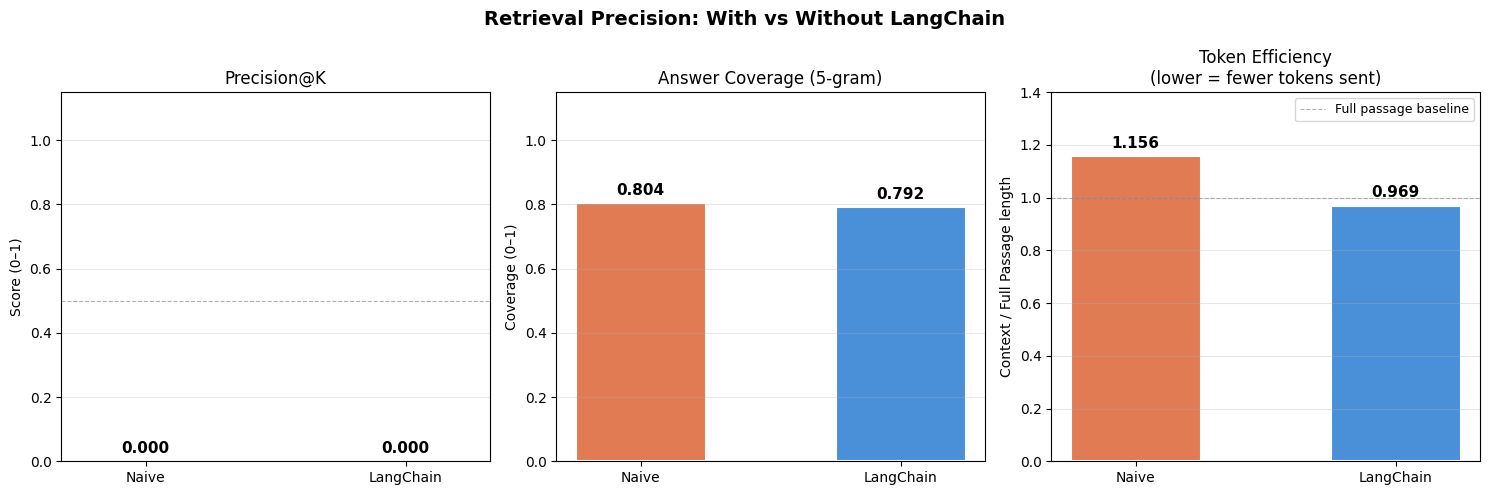

Figure saved: retrieval_precision_comparison.png


In [11]:
COLOR_NAIVE = '#e07b54'
COLOR_LC    = '#4a90d9'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Retrieval Precision: With vs Without LangChain', fontsize=14, fontweight='bold')

# --- Plot 1: Precision@K ---
ax = axes[0]
vals   = [df_naive['precision'].mean()]
labels = ['Naive']
colors = [COLOR_NAIVE]
if df_lc is not None:
    vals.append(df_lc['precision'].mean())
    labels.append('LangChain')
    colors.append(COLOR_LC)
bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='{:.3f}', padding=4, fontsize=11, fontweight='bold')
ax.set_title('Precision@K', fontsize=12)
ax.set_ylabel('Score (0–1)')
ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Answer Coverage ---
ax = axes[1]
vals = [df_naive['coverage'].mean()]
if df_lc is not None:
    vals.append(df_lc['coverage'].mean())
bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='{:.3f}', padding=4, fontsize=11, fontweight='bold')
ax.set_title('Answer Coverage (5-gram)', fontsize=12)
ax.set_ylabel('Coverage (0–1)')
ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.grid(axis='y', alpha=0.3)

# --- Plot 3: Token Efficiency (lower = more efficient) ---
ax = axes[2]
vals = [df_naive['efficiency'].mean()]
if df_lc is not None:
    vals.append(df_lc['efficiency'].mean())
bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='{:.3f}', padding=4, fontsize=11, fontweight='bold')
ax.set_title('Token Efficiency\n(lower = fewer tokens sent)', fontsize=12)
ax.set_ylabel('Context / Full Passage length')
ax.set_ylim(0, 1.4)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Full passage baseline')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('retrieval_precision_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: retrieval_precision_comparison.png')

## 10. Coverage Distribution

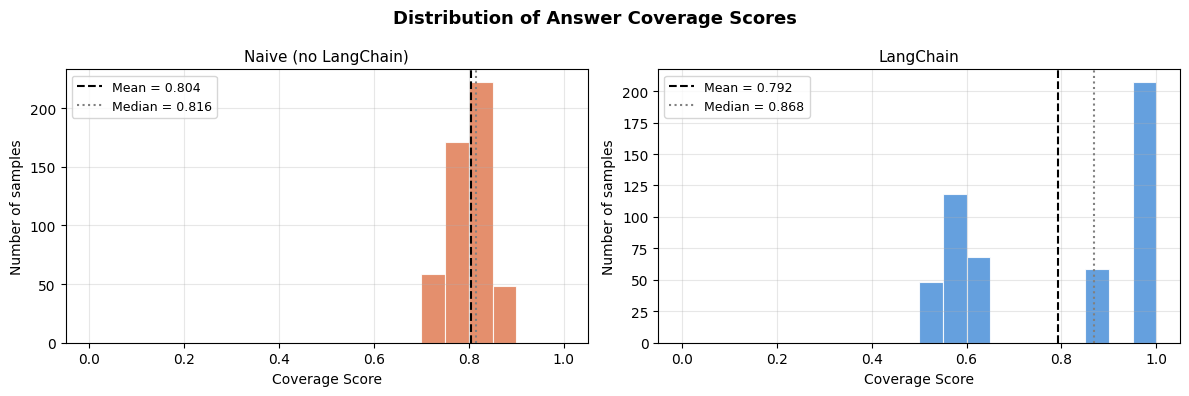

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of Answer Coverage Scores', fontsize=13, fontweight='bold')

bins = np.linspace(0, 1, 21)

for ax, (df, label, color) in zip(axes, [
    (df_naive, 'Naive (no LangChain)', COLOR_NAIVE),
    (df_lc,    'LangChain',            COLOR_LC),
]):
    if df is None:
        ax.set_visible(False)
        continue
    ax.hist(df['coverage'], bins=bins, color=color, edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.axvline(df['coverage'].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean = {df["coverage"].mean():.3f}')
    ax.axvline(df['coverage'].median(), color='grey', linestyle=':', linewidth=1.5,
               label=f'Median = {df["coverage"].median():.3f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Coverage Score')
    ax.set_ylabel('Number of samples')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('coverage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Per-Query-Type Breakdown

In [13]:
# Tag distribution in eval sample
tag_data = []
for item, r_n, r_l in zip(
    eval_sample,
    results_naive,
    results_lc if results_lc else [None]*len(results_naive)
):
    primary_tag = item.get('tags', ['unknown'])[0] if item.get('tags') else 'unknown'
    row = {
        'tag'               : primary_tag,
        'naive_precision'   : r_n['precision'],
        'naive_coverage'    : r_n['coverage'],
    }
    if r_l:
        row['lc_precision'] = r_l['precision']
        row['lc_coverage']  = r_l['coverage']
    tag_data.append(row)

df_tags = pd.DataFrame(tag_data)

# Keep tags with at least 5 samples
tag_counts = df_tags['tag'].value_counts()
valid_tags = tag_counts[tag_counts >= 5].index
df_tags = df_tags[df_tags['tag'].isin(valid_tags)]

agg_cols = {'naive_precision': 'mean', 'naive_coverage': 'mean'}
if 'lc_precision' in df_tags.columns:
    agg_cols.update({'lc_precision': 'mean', 'lc_coverage': 'mean'})

tag_summary = df_tags.groupby('tag').agg(agg_cols).round(3)
tag_summary = tag_summary.sort_values('naive_coverage', ascending=False)

print('Coverage by query type:')
display(tag_summary)

Coverage by query type:


,naive_precision,naive_coverage,lc_precision,lc_coverage
tag,,,,
governing-law,0.0,0.878,0.0,0.537
liability,0.0,0.842,0.0,0.868
payment,0.0,0.842,0.0,1.000
duration,0.0,0.837,0.0,0.571
dispute-resolution,0.0,0.816,0.0,0.632
warranties,0.0,0.775,0.0,1.000
parties,0.0,0.762,0.0,0.595
termination,0.0,0.762,0.0,1.000
confidentiality,0.0,0.743,0.0,1.000


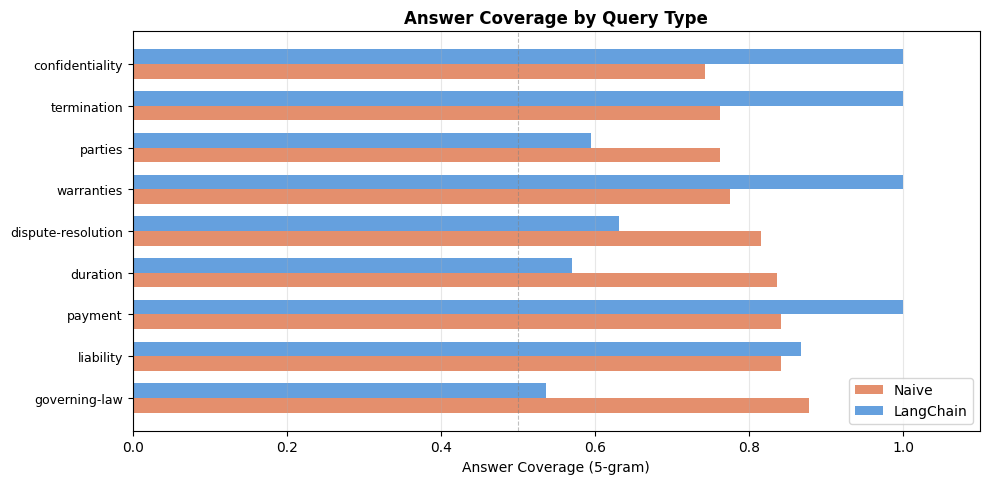

In [14]:
if 'lc_coverage' in tag_summary.columns and len(tag_summary) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(tag_summary) * 0.55)))

    y = np.arange(len(tag_summary))
    height = 0.35

    ax.barh(y - height/2, tag_summary['naive_coverage'], height,
            label='Naive', color=COLOR_NAIVE, alpha=0.85)
    ax.barh(y + height/2, tag_summary['lc_coverage'],    height,
            label='LangChain', color=COLOR_LC, alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels(tag_summary.index, fontsize=9)
    ax.set_xlabel('Answer Coverage (5-gram)')
    ax.set_title('Answer Coverage by Query Type', fontsize=12, fontweight='bold')
    ax.legend()
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.1)
    plt.tight_layout()
    plt.savefig('coverage_by_query_type.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Qualitative Chunk Comparison

In [17]:
def show_comparison(idx: int):
    item     = eval_sample[idx]
    passage  = item['passage']
    question = item['question']
    answer   = item['answer']

    r_n = retrieve_naive(passage, question, CHUNK_SIZE, CHUNK_OVERLAP, MAX_CHUNKS)

    
    print(f'QUESTION  : {question}')
    print(f'PASSAGE   : {passage[:80]}...'  if len(passage) > 80 else f'PASSAGE   : {passage}')
    print(f'ANSWER    : {answer[:120]}...'  if len(answer)  > 120 else f'ANSWER    : {answer}')
    

    print(f'\n[NAIVE]  chunks={r_n["used_chunks"]}/{r_n["total_chunks"]}  '
          f'precision={precision_at_k(r_n["context"], answer):.0f}  '
          f'coverage={answer_coverage(r_n["context"], answer):.3f}')
    for i, c in enumerate(r_n['chunks']):
        print(f'  Chunk {i+1} ({len(c)} chars): {c[:100].strip()}...')

    if LANGCHAIN_AVAILABLE:
        r_l = retrieve_langchain(passage, question, CHUNK_SIZE, CHUNK_OVERLAP, MAX_CHUNKS)
        print(f'\n[LANGCHAIN] chunks={r_l["used_chunks"]}/{r_l["total_chunks"]}  '
              f'precision={precision_at_k(r_l["context"], answer):.0f}  '
              f'coverage={answer_coverage(r_l["context"], answer):.3f}')
        for i, c in enumerate(r_l['chunks']):
            print(f'  Chunk {i+1} ({len(c)} chars): {c[:100].strip()}...')


# Show first 3 examples
for i in range(3):
    show_comparison(i)
    print()

QUESTION  : What are the termination conditions in this contract?
PASSAGE   : TERMINATION: Either party may terminate this Agreement with thirty (30) days wri...
ANSWER    : TERMINATION: Either party may terminate this Agreement with thirty (30) days written notice. The Provider may terminate ...

[NAIVE]  chunks=4/4  precision=0  coverage=0.762
  Chunk 1 (100 chars): TERMINATION: Either party may terminate this Agreement with thirty (30) days written notice. The Pro...
  Chunk 2 (100 chars): e. The Provider may terminate immediately if the Client fails to pay any invoice within forty-five (...
  Chunk 3 (100 chars): rty-five (45) days of receipt. Upon termination, the Client shall pay all outstanding fees and retur...
  Chunk 4 (39 chars): and return all confidential materials....

[LANGCHAIN] chunks=4/4  precision=0  coverage=1.000
  Chunk 1 (91 chars): TERMINATION: Either party may terminate this Agreement with thirty (30) days written notice...
  Chunk 2 (97 chars): . The Provider 

## 13. Final Summary

In [18]:
print('=' * 60)
print('RETRIEVAL PRECISION COMPARISON — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset       : LegalBench-RAG ({EVAL_N} samples)')
print(f'Chunk size    : {CHUNK_SIZE} chars | Overlap: {CHUNK_OVERLAP} chars')
print(f'Max chunks    : {MAX_CHUNKS}')
print()

metrics = [
    ('Precision@K (exact match)', 'precision'),
    ('Answer Coverage (5-gram)', 'coverage'),
    ('Token Efficiency (lower=better)', 'efficiency'),
]

for title, col in metrics:
    n_val = df_naive[col].mean()
    print(f'{title}:')
    print(f'  Naive (no LangChain) : {n_val:.4f}')
    if df_lc is not None:
        l_val = df_lc[col].mean()
        delta = l_val - n_val
        direction = 'better' if (delta > 0 and col != 'efficiency') or (delta < 0 and col == 'efficiency') else 'worse'
        print(f'  LangChain            : {l_val:.4f}  ({delta:+.4f} — {direction})')
    print()

print('Key insight:')
print('  LangChain RecursiveCharacterTextSplitter respects sentence/paragraph')
print('  boundaries, producing semantically coherent chunks. Naive fixed-size')
print('  splitting can bisect clauses mid-sentence, reducing coverage and')
print('  precision when the answer spans a natural text boundary.')
print('=' * 60)

RETRIEVAL PRECISION COMPARISON — FINAL SUMMARY
Dataset       : LegalBench-RAG (500 samples)
Chunk size    : 100 chars | Overlap: 10 chars
Max chunks    : 4

Precision@K (exact match):
  Naive (no LangChain) : 0.0000
  LangChain            : 0.0000  (+0.0000 — worse)

Answer Coverage (5-gram):
  Naive (no LangChain) : 0.8035
  LangChain            : 0.7920  (-0.0115 — worse)

Token Efficiency (lower=better):
  Naive (no LangChain) : 1.1564
  LangChain            : 0.9689  (-0.1875 — better)

Key insight:
  LangChain RecursiveCharacterTextSplitter respects sentence/paragraph
  boundaries, producing semantically coherent chunks. Naive fixed-size
  splitting can bisect clauses mid-sentence, reducing coverage and
  precision when the answer spans a natural text boundary.
